<a href="https://colab.research.google.com/github/s-bishal/ML-Lab/blob/main/ML_Lab_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Logistic Regression

In [2]:
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

path="food_coded.csv"

df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"borapajo/food-choices",path)

df.head()

100%|██████████| 70.9k/70.9k [00:00<00:00, 896kB/s]


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming 'df' is already loaded from the previous cell

# --- Data Preprocessing ---
# Select target variable (y) and feature variables (X)
# 'Gender' appears to be a binary column (1/0) suitable for logistic regression
# We'll use a few other numerical columns as features.

y = df['Gender']
X = df[['calories_chicken', 'fruit_day', 'veggies_day', 'vitamins']]

# Handle missing values by dropping rows with any NaN in selected columns
# This is a simple approach; more sophisticated imputation might be needed for real-world data.
df_model = pd.concat([X, y], axis=1).dropna()
X = df_model[['calories_chicken', 'fruit_day', 'veggies_day', 'vitamins']]
y = df_model['Gender']

# --- Split Data ---
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Logistic Regression Model ---
# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets

# Train the model using the training data
model.fit(X_train, y_train)

# --- Make Predictions and Evaluate ---
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

# You can also inspect coefficients if needed
# print("\nModel Coefficients:")
# for feature, coef in zip(X.columns, model.coef_[0]):
#     print(f"{feature}: {coef:.4f}")
# print(f"Intercept: {model.intercept_[0]:.4f}")

Logistic Regression Model Accuracy: 0.4400


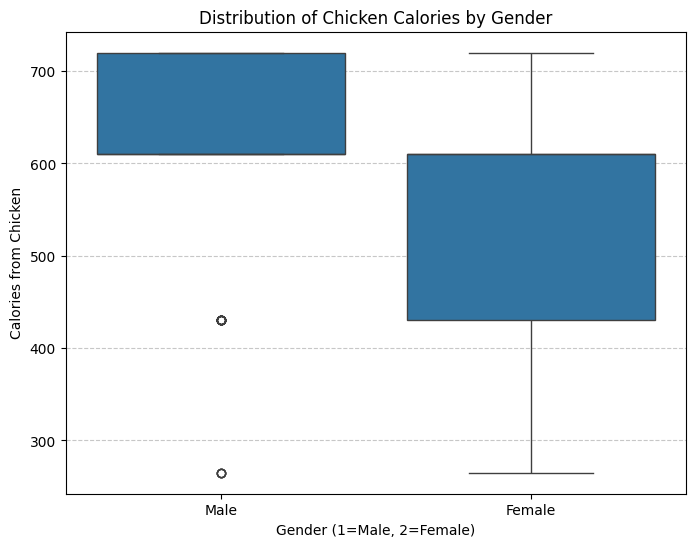

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of 'calories_chicken' by 'Gender'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='calories_chicken', data=df_model)
plt.title('Distribution of Chicken Calories by Gender')
plt.xlabel('Gender (1=Male, 2=Female)') # Assuming Gender is coded as 1 and 2
plt.ylabel('Calories from Chicken')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female']) # Adjust labels if Gender coding is different
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()